# 1. Business Understanding
### 1.1 Background

The stock market plays a crucial role in economic development by enabling companies to raise capital and providing investors with opportunities to grow their wealth. In Kenya, the Nairobi Securities Exchange serves as the primary platform where publicly listed companies trade their shares.

Investors often rely on historical price trends, financial analysis, and market news when making investment decisions. However, predicting stock price movements remains a complex task due to market volatility, investor behavior, and external economic influences.

One of the most actively traded companies on the exchange is Safaricom. Due to its large market capitalization and high trading volume, Safaricom plays a significant role in influencing overall market activity. Analyzing and forecasting its stock price movements can therefore provide useful insights into investment strategies and market dynamics.

With the availability of historical market data and advancements in machine learning techniques, it is now possible to build predictive models that can identify patterns in stock price movements. These models can assist investors and analysts in making more informed decisions by estimating future price trends based on historical data.




### 1.2 Market Research

This section explains:

- how the Nairobi Securities Exchange works
- importance of stock prediction
- importance of Safaricom in the market
- existing prediction methods

The `Nairobi Securities Exchange`(NSE) is the primary securities exchange in Kenya where publicly listed companies trade shares and other financial instruments. The exchange plays a significant role in facilitating investment, capital formation, and economic growth within the country.

Stock prices in financial markets are influenced by a variety of factors including company performance, macroeconomic conditions, investor sentiment, and trading activity. As a result, forecasting stock price movements has become an important area of research in finance and data science.

Among the companies listed on the exchange, `Safaricom` is one of the most actively traded stocks. Due to its large market capitalization and high liquidity, Safaricom frequently accounts for a significant portion of total trading activity in the market. This makes it an important case study for analyzing stock price behavior in the Kenyan market.

In recent years, machine learning and data-driven approaches have been increasingly applied to financial forecasting. Techniques such as regression models, tree-based algorithms, and neural networks have shown potential in identifying hidden patterns within historical financial data. These methods can complement traditional financial analysis by providing predictive insights based on historical trading patterns.

By leveraging historical trading data from the Nairobi Securities Exchange, this project explores how machine learning techniques can be applied to predict stock prices and identify potential investment opportunities within the Kenyan market.

### 1.3. Problem Statement

Predicting stock price movements remains a significant challenge due to the dynamic and unpredictable nature of financial markets. Investors in the Nairobi Securities Exchange often rely on historical price trends and manual analysis when making investment decisions, which may not always capture hidden patterns within large datasets.

Despite the availability of historical trading data, there is limited use of data-driven predictive models specifically focused on stocks listed in the Kenyan market. This creates an opportunity to explore how machine learning techniques can be used to analyze historical stock data and generate reliable price forecasts.

This project seeks to develop a predictive model capable of estimating the next-day closing price of Safaricom using historical trading data. Additionally, the study will extend the analysis to a broader market perspective by applying the model to multiple stocks listed on the Nairobi Securities Exchange in order to identify the top 20 stocks with the highest predicted returns.


### 1.4. Objectives
#### Main Objective

To develop a machine learning model that predicts future stock prices using historical trading data from the Nairobi Securities Exchange.

Specific Objectives

1. To analyze historical trading data of Safaricom stock from 2007 to 2025.
2. To perform exploratory data analysis in order to understand price trends, volatility, and trading patterns..
3. To train and evaluate multiple machine learning models for predicting next-day stock prices.
4. To extend the prediction model to multiple stocks listed on the Nairobi Securities Exchange.
5. To rank stocks based on predicted returns and identify the top 20 potentially high-performing stocks.


### 1.5. Stakeholders

Several stakeholders may benefit from insights generated in this project:

1. Investors and Traders
- Individual and institutional investors can use predictive insights to support investment decision-making and identify potential opportunities within the stock market.

2. Financial Analysts
- Market analysts can utilize predictive models to complement traditional financial analysis methods when evaluating stock performance.

3. tock Brokerage Firms
- Brokerage firms may use predictive insights to provide data-driven recommendations to their clients.

4. Researchers and Data Scientists
- This project contributes to the growing field of financial data science by demonstrating how machine learning techniques can be applied to stock market prediction using local market data.

5. The Nairobi Securities Exchange
- Insights derived from this analysis may contribute to a deeper understanding of trading patterns and market dynamics within the exchange.

# 2. Data Understanding
### 2.1 Data Sources

The dataset used in this project consists of historical stock market trading data from the Nairobi Securities Exchange covering the period `2007` to `OCT 2025`. The data contains daily trading records for multiple companies listed on the exchange.

Each record includes information such as the trading date, stock code, company name, daily price movements, trading volume, and other related indicators.

The dataset was collected in multiple files organized by year. To facilitate analysis, the files are combined into a single dataset that contains all trading records within the study period.

*importing the required libraries and loading the data* 

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
# Define the data path
DATA_PATH = Path("../data/raw_data")

print(DATA_PATH)

..\data\raw_data


First, we load a sample file to inspect the data. 

In [4]:
# Load the 2007 data into a variable
df_2007 = pd.read_csv(DATA_PATH / "NSE_data_all_stocks_2007.csv")

# Inspect the first 5 rows
df_2007.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


In [5]:
# Inspect the datasets details (nulls, number of columns etc.)
df_2007.info()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   DATE       10608 non-null  str  
 1   CODE       10608 non-null  str  
 2   NAME       10585 non-null  str  
 3   12m Low    10608 non-null  str  
 4   12m High   10608 non-null  str  
 5   Day Low    10608 non-null  str  
 6   Day High   10608 non-null  str  
 7   Day Price  10608 non-null  str  
 8   Previous   10608 non-null  str  
 9   Change     10608 non-null  str  
 10  Change%    10608 non-null  str  
 11  Volume     10608 non-null  str  
 12  Adjust     10608 non-null  str  
dtypes: str(13)
memory usage: 1.1 MB


In [6]:
# Print columns
df_2007.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust'],
      dtype='str')

### Combine All Datasets
As mentioned ealier, we are combining the datasets under one variable for easy access 

In [7]:
# Find all files in the raw_data folder
files = glob.glob("../data/raw_data/*.csv")

# Ensure all files are found
files

['../data/raw_data\\NSE_data_all_stocks_2007-2025.csv',
 '../data/raw_data\\NSE_data_all_stocks_2007.csv',
 '../data/raw_data\\NSE_data_all_stocks_2008.csv',
 '../data/raw_data\\NSE_data_all_stocks_2009.csv',
 '../data/raw_data\\NSE_data_all_stocks_2010.csv',
 '../data/raw_data\\NSE_data_all_stocks_2011.csv',
 '../data/raw_data\\NSE_data_all_stocks_2012.csv',
 '../data/raw_data\\NSE_data_all_stocks_2013.csv',
 '../data/raw_data\\NSE_data_all_stocks_2014.csv',
 '../data/raw_data\\NSE_data_all_stocks_2015.csv',
 '../data/raw_data\\NSE_data_all_stocks_2016.csv',
 '../data/raw_data\\NSE_data_all_stocks_2017.csv',
 '../data/raw_data\\NSE_data_all_stocks_2018.csv',
 '../data/raw_data\\NSE_data_all_stocks_2019.csv',
 '../data/raw_data\\NSE_data_all_stocks_2020.csv',
 '../data/raw_data\\NSE_data_all_stocks_2021.csv',
 '../data/raw_data\\NSE_data_all_stocks_2022.csv',
 '../data/raw_data\\NSE_data_all_stocks_2023.csv',
 '../data/raw_data\\NSE_data_all_stocks_2024.csv',
 '../data/raw_data\\NSE_da

In [8]:
# Create an empty list
dfs = []

# Loop over every file and read the contents
for file in files:
    df = pd.read_csv(file)

    # Append the dataframes to the empty list, dfs, to create a list of dataframes with no index
    dfs.append(df)

C:\Users\User\AppData\Local\Temp\ipykernel_20828\4220449471.py:6: DtypeWarning: Columns (0: DATE, 1: CODE, 2: NAME, 3: Adjust, 4: Date, 5: Adjusted, 6: Code, 7: Name, 8: Adjusted Price) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


In [9]:
# Concatenate the dataframes to create one dataframe
combined_df = pd.concat(dfs, ignore_index=True)

# Review the first 15 rows
combined_df.head(15)

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,DATE,CODE,NAME,12m Low,12m High,Day Low,...,Previous,Change,Change%,Volume,Adjust,Date,Adjusted,Code,Name,Adjusted Price
0,0.0,0.0,0.0,0.0,1/2/2007,EGAD,Eaagads,22,57,52,...,52,-,-,300,26,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,1.0,1/2/2007,KAPC,Kapchorua Tea,111,148,100,...,98.5,1.5,1.50%,"7,800",-,NaN,NaN,NaN,NaN,NaN
2,2.0,2.0,2.0,2.0,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,...,42.25,1.25,2.87%,"2,700",-,NaN,NaN,NaN,NaN,NaN
3,3.0,3.0,3.0,3.0,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,...,25.75,-0.25,0.98%,"10,500",-,NaN,NaN,NaN,NaN,NaN
4,4.0,4.0,4.0,4.0,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,...,141,-1,0.71%,"70,900",23.33,NaN,NaN,NaN,NaN,NaN
5,5.0,5.0,5.0,5.0,1/2/2007,UTK,Unilever Tea Kenya,45,45,80,...,81.5,-0.5,0.62%,"1,000",-,NaN,NaN,NaN,NaN,NaN
6,6.0,6.0,6.0,6.0,1/2/2007,WTK,Williamson Tea Kenya,180,290,120,...,118,2,1.67%,"10,000",-,NaN,NaN,NaN,NaN,NaN
7,7.0,7.0,7.0,7.0,1/2/2007,C&G,Car and General (K),21,29,50,...,50,-,-,"66,700",33.33,NaN,NaN,NaN,NaN,NaN
8,8.0,8.0,8.0,8.0,1/2/2007,CMC,CMC Holdings,13.5,13.5,173,...,173,15,7.98%,"36,200",15.67,NaN,NaN,NaN,NaN,NaN
9,9.0,9.0,9.0,9.0,1/2/2007,FIRE,Sameer Africa,3.4,5.95,22.5,...,24,0.75,3.03%,"54,800",-,NaN,NaN,NaN,NaN,NaN


In [10]:
# Review the last 15 rows
combined_df.tail(15)

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,DATE,CODE,NAME,12m Low,12m High,Day Low,...,Previous,Change,Change%,Volume,Adjust,Date,Adjusted,Code,Name,Adjusted Price
1505010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.27,0.27,0.27,...,0.27,-,-,-,NaN,31-Oct-25,NaN,MSC,Mumias Sugar Company Ltd,-
1505011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.8,9.0,7.28,...,8.06,-0.6,-7.44%,6820,NaN,31-Oct-25,NaN,SKL,Shri Krishana Overseas Plc,-
1505012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.4,28.25,24.5,...,24.7,-0.05,-0.20%,1569,NaN,31-Oct-25,NaN,UNGA,Unga Group Ltd,-
1505013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.1,31.0,29.6,...,29.55,0.7,2.37%,3051822,NaN,31-Oct-25,NaN,SCOM,Safaricom Plc,-
1505014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,20.0,20.0,...,20,-,-,-,NaN,31-Oct-25,NaN,LAPR,Laptrust Imara Income-REIT,-
1505015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,9800.0,4840.0,...,4835,75,1.55%,539,NaN,31-Oct-25,NaN,GLD,ABSA NewGold ETF,-
1505016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,755.0,1000.0,854.0,...,857,-2,-0.23%,27,NaN,31-Oct-25,NaN,SMWF,Satrix MSCI World Feeder ETF,-
1505017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1170.1,1934.23,1910.77,...,1877.52,33.25,1.77%,-,NaN,31-Oct-25,NaN,^N10I,NSE 10-Share Index,-
1505018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1823.17,3153.39,3116.69,...,3090.7,25.99,0.84%,-,NaN,31-Oct-25,NaN,^N20I,NSE 20-Share Index,-
1505019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3063.32,5052.98,4998.39,...,4900.89,97.5,1.99%,-,NaN,31-Oct-25,NaN,^N25I,NSE 25-Share Index,-


In [11]:
# Turn it into a CSV file
combined_df.to_csv("../data/raw_data/processed/NSE_data_all_stocks_2007-2025.csv", index=False)

#### Inspect the merged data

In [12]:
# Shape of the dataset
print("Rows, Columns:", combined_df.shape)

Rows, Columns: (1505025, 22)


In [13]:
combined_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'DATE',
       'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price'],
      dtype='str')

In [14]:
# Data types and non-null values
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1505025 entries, 0 to 1505024
Data columns (total 22 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Unnamed: 0.3    1204020 non-null  float64
 1   Unnamed: 0.2    903015 non-null   float64
 2   Unnamed: 0.1    602010 non-null   float64
 3   Unnamed: 0      301005 non-null   float64
 4   DATE            1115535 non-null  str    
 5   CODE            1168450 non-null  str    
 6   NAME            1168210 non-null  str    
 7   12m Low         1505015 non-null  object 
 8   12m High        1505015 non-null  object 
 9   Day Low         1505015 non-null  object 
 10  Day High        1505015 non-null  object 
 11  Day Price       1505015 non-null  object 
 12  Previous        1505015 non-null  str    
 13  Change          1505015 non-null  str    
 14  Change%         1505015 non-null  str    
 15  Volume          1505015 non-null  str    
 16  Adjust          1115535 non-null  str    
 17  

In [15]:
# Summary stats for numerical columns
combined_df.describe()

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0
count,1.204020e+06,903015.000000,602010.000000,301005.000000
mean,6.020095e+05,451507.000000,301004.500000,150502.000000
std,3.475708e+05,260678.121004,173785.462115,86892.803226
min,0.000000e+00,0.000000,0.000000,0.000000
25%,3.010048e+05,225753.500000,150502.250000,75251.000000
50%,6.020095e+05,451507.000000,301004.500000,150502.000000
75%,9.030142e+05,677260.500000,451506.750000,225753.000000
max,1.204019e+06,903014.000000,602009.000000,301004.000000


In [16]:
# Check unique values for each column (useful for categorical vars)
combined_df.nunique()

Unnamed: 0.3      1204020
Unnamed: 0.2       903015
Unnamed: 0.1       602010
Unnamed: 0         301005
DATE                 3491
CODE                   99
NAME                  143
12m Low               991
12m High             1132
Day Low             24923
Day High            24910
Day Price           25760
Previous            21596
Change               5960
Change%              2353
Volume              31270
Adjust               3905
Date                 1195
Adjusted             1063
Code                   79
Name                   81
Adjusted Price         45
dtype: int64

In [17]:
# Total and percent missing
missing = combined_df.isnull().sum()
missing_percent = (missing / len(combined_df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percent': missing_percent})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percent
Unnamed: 0.3,301005,20.000000
Unnamed: 0.2,602010,40.000000
Unnamed: 0.1,903015,60.000000
Unnamed: 0,1204020,80.000000
DATE,389490,25.879304
CODE,336575,22.363416
NAME,336815,22.379362
12m Low,10,0.000664
12m High,10,0.000664
Day Low,10,0.000664


In [18]:
# Check duplicates
combined_df.duplicated().sum()

np.int64(89)

## Data Cleaning

Data cleaning is a critical step in the data science workflow that involves identifying and correcting errors, inconsistencies, and inaccuracies in a dataset. Raw data collected from different sources or across long time periods often contains issues such as missing values, inconsistent column naming, duplicate variables, incorrect data formats, and redundant information. If these issues are not addressed, they can negatively affect the quality of analysis and the performance of predictive models.

In the context of this project, the Nairobi Securities Exchange (NSE) dataset was compiled from multiple yearly records spanning from 2007 to 2025. Because the data originates from different time periods and potentially different reporting formats, several inconsistencies were observed during the data understanding phase. These include variations in column naming conventions (for example, `DATE` vs `Date`), duplicate columns representing the same variable, automatically generated index columns, and missing values resulting from the merging process.

The objective of the data cleaning stage is therefore to transform the raw merged dataset into a structured and consistent format suitable for analysis and modeling. The key steps performed in this phase include:

- Resolving inconsistencies in column names.
- Merging duplicate columns representing the same variables.
- Removing redundant or unnecessary columns.
- Standardizing the structure and ordering of dataset columns.
- Preparing the dataset for further preprocessing steps such as data type conversion and exploratory data analysis.

By completing these cleaning steps, the dataset becomes more reliable and suitable for downstream tasks including exploratory analysis, feature engineering, and the development of machine learning models for stock price prediction.

### Handling Column Name Inconsistencies

After merging the NSE datasets from multiple years, several duplicated columns were identified. These duplicates occurred because different datasets used different capitalization styles for the same variables.

Examples include:

| Column Version 1 | Column Version 2 |
|------------------|------------------|
| DATE | Date |
| CODE | Code |
| NAME | Name |
| Adjust | Adjusted |
| Adjusted Price | Adjust |

Because pandas treats column names as case-sensitive, these columns were interpreted as separate variables during the merge process. As a result, some rows contain values in one column while the corresponding duplicate column contains missing values.

### Cleaning Strategy

To resolve this issue:

1. Merge duplicated columns representing the same variable.
2. Fill missing values in one column using values from the other column.
3. Retain a single standardized column name.
4. Remove redundant columns after merging.

This ensures the dataset maintains a consistent schema across all observations.

In [19]:
combined_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'DATE',
       'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price'],
      dtype='str')

In [20]:
# combine Date and DATE columns into one column called date
combined_df['date'] = combined_df['DATE'].fillna(combined_df['Date'])

In [21]:
# check the new date column for nulls
combined_df['date'].isna().sum()

np.int64(10)

In [22]:
# combine Code and CODE columds
combined_df['code'] = combined_df['CODE'].fillna(combined_df['Code'])

In [23]:
#Check the code colums for nulls
combined_df['code'].isna().sum()

np.int64(10)

In [24]:
# combine name and NAME columns
combined_df['name'] = combined_df['NAME'].fillna(combined_df['Name'])

In [25]:
# check the name column for nulls
combined_df['name'].isna().sum()

np.int64(250)

In [26]:
# combine Adjusted Price, Adjust and Adjusted columns into one column called adjusted_price
combined_df['adjusted_price'] = combined_df['Adjusted Price'].fillna(combined_df['Adjust'])
combined_df['adjusted_price'] = combined_df['adjusted_price'].fillna(combined_df['Adjusted'])

In [27]:
combined_df['adjusted_price'].isna().sum()

np.int64(10)

In [28]:
combined_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'DATE',
       'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price', 'date', 'code',
       'name', 'adjusted_price'],
      dtype='str')

In [29]:
# drop the original columns that have been combined into new columns
combined_df = combined_df.drop(columns=[
'DATE','Date',
'CODE','Code',
'NAME','Name',
'Adjust','Adjusted','Adjusted Price'
])

In [30]:
combined_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', '12m Low',
       '12m High', 'Day Low', 'Day High', 'Day Price', 'Previous', 'Change',
       'Change%', 'Volume', 'date', 'code', 'name', 'adjusted_price'],
      dtype='str')

In [31]:
combined_df.head()

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,date,code,name,adjusted_price
0,0.0,0.0,0.0,0.0,22,57,52,52,52,52,-,-,300,1/2/2007,EGAD,Eaagads,26
1,1.0,1.0,1.0,1.0,111,148,100,100,100,98.5,1.5,1.50%,"7,800",1/2/2007,KAPC,Kapchorua Tea,-
2,2.0,2.0,2.0,2.0,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",1/2/2007,KUKZ,Kakuzi,-
3,3.0,3.0,3.0,3.0,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",1/2/2007,REA,Rea Vipingo Plantations,-
4,4.0,4.0,4.0,4.0,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",1/2/2007,SASN,Sasini Tea and Coffee,23.33


## Column Cleanup and Standardization

After merging and consolidating duplicate columns, the dataset still contained unnecessary index columns (`Unnamed: 0` and `Unnamed: 0.1`). These columns were automatically generated during previous CSV exports and do not contain meaningful analytical information.

To prepare the dataset for analysis, the following steps were performed:

1. Remove redundant index columns (`Unnamed: 0`, `Unnamed: 0.1`).
2. Standardize column names to a consistent naming format.
3. Reorder the columns to match the desired schema for analysis.

The final dataset structure will be:

Date, Code, Name, 12m Low, 12m High, Day Low, Day High, Day Price, Previous, Change, Change%, Volume, Adjusted Price

This structure ensures clarity and consistency before proceeding to data type corrections and exploratory analysis.

In [32]:
combined_df = combined_df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore')

In [33]:
# standardize column names to lowercase and replace spaces with underscores
combined_df.columns = combined_df.columns.str.lower().str.replace(' ', '_')

In [34]:
combined_df.columns

Index(['unnamed:_0.3', 'unnamed:_0.2', '12m_low', '12m_high', 'day_low',
       'day_high', 'day_price', 'previous', 'change', 'change%', 'volume',
       'date', 'code', 'name', 'adjusted_price'],
      dtype='str')

In [35]:
combined_df = combined_df[[
'date',
'code',
'name',
'12m_low',
'12m_high',
'day_low',
'day_high',
'day_price',
'previous',
'change',
'change%',
'volume',
'adjusted_price'
]]

combined_df.head()

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


check for missing data after the merge

In [36]:
# Total and percent missing
missing_merged = combined_df.isnull().sum()
missing_percent = (missing_merged / len(combined_df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_merged, 'Percent': missing_percent})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percent
date,10,0.000664
code,10,0.000664
name,250,0.016611
12m_low,10,0.000664
12m_high,10,0.000664
day_low,10,0.000664
day_high,10,0.000664
day_price,10,0.000664
previous,10,0.000664
change,10,0.000664


In [37]:
# generate a copy of a final dataset
combined_df.to_csv("../data/raw_data/processed/nse_final_dataset.csv", index=False)

In [38]:
combined_df.describe()

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
count,1505015,1505015,1504775,1505015,1505015,1505015,1505015,1505015,1505015,1505015,1505015,1505015,1505015
unique,4686,107,154,991,1132,24923,24910,25760,21596,5960,2353,31270,4031
top,24-Mar-17,HFCK,NSE 20-Share Index,4,55.5,5.5,5.5,5.5,5.5,-,-,-,-
freq,690,23450,22430,28445,19240,14892,14721,13661,13690,556305,556840,331990,1317405


#### Data Type Correction

After completing the initial data cleaning process and producing a consolidated dataset, the next step involves correcting the data types of several variables. When datasets are imported from CSV files, columns containing numeric values may sometimes be interpreted as text due to the presence of formatting characters such as commas or percentage signs.

For example, columns such as **Volume** may contain values formatted with commas (e.g., "7,800"), while **Change%** includes percentage symbols (e.g., "1.50%"). Additionally, the **Date** column is initially stored as a string rather than a datetime object.

These formatting issues prevent proper numerical analysis and must therefore be corrected. In this stage, the dataset will be prepared for analysis by:

- Converting the **Date** column to a datetime format.
- Removing commas from the **Volume** column and converting it to numeric.
- Removing percentage symbols from **Change%** and converting it to a numeric value.
- Ensuring all price-related columns are stored as numeric data types.

Correcting these data types ensures that the dataset can be used effectively for exploratory analysis and machine learning models.

Using the `nse_final_dataset.csv` to continue with data cleaning

In [39]:
# load the final dataset to confirm it was saved correctly
cleaning_df = pd.read_csv("../data/raw_data/processed/nse_final_dataset.csv")

cleaning_df.head()

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


In [40]:
# check current data types
cleaning_df.dtypes

date              str
code              str
name              str
12m_low           str
12m_high          str
day_low           str
day_high          str
day_price         str
previous          str
change            str
change%           str
volume            str
adjusted_price    str
dtype: object

After loading the cleaning dataset, all columns were interpreted as strings (`str`). This commonly occurs when importing data from CSV files that contain formatting characters such as commas, percentage signs, or placeholder symbols (e.g., "-").

For instance:
- The **Volume, 12m_low, 12m_high, day_low, day_high, day_price, etc.** column contains comma-separated values such as "7,800".
- The **Change%** column includes percentage symbols such as "1.50%".
- Some numeric columns may contain "-" to indicate missing values.

Because machine learning models and statistical analysis require numeric data types, these columns must be converted to their appropriate formats.

The following transformations will be applied:

- Convert **Date** from string to datetime.
- Remove commas from **Volume, 12m_low, 12m_high, day_low, day_high, day_price, etc.** and convert it to a numeric value.
- Remove the `%` symbol from **Change%** and convert it to a float.
- Convert all price-related columns to numeric values.
- Replace invalid placeholders (e.g., "-") with 0, this is because the dash in stock market doesn't necessarily mean the data is missing. For example, in `change` the dash migh mean 0, there was no change in prices during that day.

In [41]:
cleaning_df.tail(50)

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
1504975,31-Oct-25,NMG,Nation Media Group Plc,10.05,15.5,13.5,13.5,13.5,13.55,-0.05,-0.37%,772,-
1504976,31-Oct-25,SMER,Sameer Africa Plc,2.11,17.0,14.7,15.0,15.0,15.25,-0.25,-1.64%,3588,-
1504977,31-Oct-25,SGL,Standard Group Plc,4.5,7.14,6.0,6.4,6.08,6,0.08,1.33%,7157,-
1504978,31-Oct-25,TPSE,TPS Eastern Africa (Serena) Ltd,12.35,18.7,16.2,16.5,16.3,16.25,0.05,0.31%,28020,-
1504979,31-Oct-25,UCHM,Uchumi Supermarket Plc,0.16,0.44,0.35,0.38,0.36,0.35,0.01,2.86%,103079,-
1504980,31-Oct-25,SCAN,WPP ScanGroup Plc,1.8,4.02,2.79,2.9,2.8,2.8,-,-,108216,-
1504981,31-Oct-25,ARM,ARM Cement Plc,5.55,5.55,5.55,5.55,5.55,5.55,-,-,-,-
1504982,31-Oct-25,BAMB,Bamburi Cement Ltd,47.0,68.0,47.2,47.2,47.2,47.2,-,-,-,-
1504983,31-Oct-25,CRWN,Crown Paints Kenya Plc,29.0,62.0,48.6,53.5,50.25,54,-3.75,-6.94%,1407,-
1504984,31-Oct-25,CABL,East African Cables Plc,0.98,3.27,1.0,1.0,1.0,1,-,-,-,-


- As seen above, we see that in most cases where we have `-` in the `change` column, there is no chaneg in `day_price` and `previous`.

- Also, with no change in price, normally the volume also remains at 0, meaning that no trades were done that day. However, we also have instances where there's some changes in price but the row has `-` in the `volume` column, this as also seen in the table above, is mostly when the company is an index. Indices cannot have volume in the traditional sense because they are not actual, traded assets; they are merely mathematical calculations representing the weighted average price of a group of stocks. Unlike stocks, which represent ownership in a company that can be bought and sold, you cannot trade the index directly. 

In [42]:
cleaning_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1505025 entries, 0 to 1505024
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   date            1505015 non-null  str  
 1   code            1505015 non-null  str  
 2   name            1504775 non-null  str  
 3   12m_low         1505015 non-null  str  
 4   12m_high        1505015 non-null  str  
 5   day_low         1505015 non-null  str  
 6   day_high        1505015 non-null  str  
 7   day_price       1505015 non-null  str  
 8   previous        1505015 non-null  str  
 9   change          1505015 non-null  str  
 10  change%         1505015 non-null  str  
 11  volume          1505015 non-null  str  
 12  adjusted_price  1505015 non-null  str  
dtypes: str(13)
memory usage: 149.3 MB


So far, all the columns have values stored as `object`. Here, we will be trying to clean the data so that it will be ready to be coverted to the right datatypes.

In the next cell, we are writing a code that;
- Strips whitespace and invisible characters from all columns.
- Removes commas, so numbers like 1,234 become 1234.
- Replaces `-` with 0, which is safe for volume, change, and %change.
- Converts all columns to numeric (float), so your models won’t break.
- Keeps all rows, only truly invalid data becomes NaN.

In [43]:
# List of columns to clean
price_cols = ['12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 
              'previous', 'change', 'change%', 'volume']

# Ensure all are strings
cleaning_df[price_cols] = cleaning_df[price_cols].astype(str)

# Remove common unwanted characters
for col in price_cols:
    cleaning_df[col] = cleaning_df[col].str.replace(',','')       # remove commas
    cleaning_df[col] = cleaning_df[col].str.replace('\xa0','', regex=False)  # remove non-breaking spaces
    cleaning_df[col] = cleaning_df[col].str.strip()              # remove leading/trailing spaces
    cleaning_df[col] = cleaning_df[col].replace('-', '0')        # replace '-' with 0
    cleaning_df[col] = cleaning_df[col].str.replace('%', '', regex=True)

# Convert to numeric
cleaning_df[price_cols] = cleaning_df[price_cols].apply(pd.to_numeric, errors='coerce')

# Optional sanity check
print(cleaning_df[price_cols].dtypes)

12m_low      float64
12m_high     float64
day_low      float64
day_high     float64
day_price    float64
previous     float64
change       float64
change%      float64
volume       float64
dtype: object


In [44]:
# Ensure no nulls arise
cleaning_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1505025 entries, 0 to 1505024
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            1505015 non-null  str    
 1   code            1505015 non-null  str    
 2   name            1504775 non-null  str    
 3   12m_low         1505015 non-null  float64
 4   12m_high        1505015 non-null  float64
 5   day_low         1505015 non-null  float64
 6   day_high        1505015 non-null  float64
 7   day_price       1505015 non-null  float64
 8   previous        1505015 non-null  float64
 9   change          1505015 non-null  float64
 10  change%         1505015 non-null  float64
 11  volume          1505015 non-null  float64
 12  adjusted_price  1505015 non-null  str    
dtypes: float64(9), str(4)
memory usage: 149.3 MB


#### Datetime


In [45]:
cleaning_df['date']

0           1/2/2007
1           1/2/2007
2           1/2/2007
3           1/2/2007
4           1/2/2007
             ...    
1505020    31-Oct-25
1505021    31-Oct-25
1505022    31-Oct-25
1505023    31-Oct-25
1505024    31-Oct-25
Name: date, Length: 1505025, dtype: str

In [46]:
cleaning_df['date'].astype(str).str.strip().unique()

<StringArray>
[ '1/2/2007',  '1/3/2007',  '1/4/2007',  '1/5/2007',  '1/8/2007',  '1/9/2007',
 '1/10/2007', '1/11/2007', '1/12/2007', '1/15/2007',
 ...
 '16-Oct-25', '21-Oct-25', '22-Oct-25', '23-Oct-25', '24-Oct-25', '27-Oct-25',
 '28-Oct-25', '29-Oct-25', '30-Oct-25', '31-Oct-25']
Length: 4687, dtype: str

In [47]:
cleaning_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1505025 entries, 0 to 1505024
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            1505015 non-null  str    
 1   code            1505015 non-null  str    
 2   name            1504775 non-null  str    
 3   12m_low         1505015 non-null  float64
 4   12m_high        1505015 non-null  float64
 5   day_low         1505015 non-null  float64
 6   day_high        1505015 non-null  float64
 7   day_price       1505015 non-null  float64
 8   previous        1505015 non-null  float64
 9   change          1505015 non-null  float64
 10  change%         1505015 non-null  float64
 11  volume          1505015 non-null  float64
 12  adjusted_price  1505015 non-null  str    
dtypes: float64(9), str(4)
memory usage: 149.3 MB


In [48]:
cleaning_df['date_test'] = cleaning_df['date'].astype(str).str.strip()


In [49]:
date1 = pd.to_datetime(cleaning_df['date_test'], format= '%d-%b-%y', errors='coerce')

In [50]:
date2 = pd.to_datetime(cleaning_df['date_test'], format= '%m/%d/%Y', errors='coerce')

In [51]:
cleaning_df['date_parsed'] = date1.fillna(date2)

In [52]:
cleaning_df['date_parsed'].isna().sum()

np.int64(10)

In [53]:
problem_dates = cleaning_df[cleaning_df['date_parsed'].isna()]

In [54]:
problem_dates

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_test,date_parsed
112088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
179906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
413093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
480911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
714098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
781916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1015103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1082921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1316108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1383926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [55]:
cleaning_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1505025 entries, 0 to 1505024
Data columns (total 15 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   date            1505015 non-null  str           
 1   code            1505015 non-null  str           
 2   name            1504775 non-null  str           
 3   12m_low         1505015 non-null  float64       
 4   12m_high        1505015 non-null  float64       
 5   day_low         1505015 non-null  float64       
 6   day_high        1505015 non-null  float64       
 7   day_price       1505015 non-null  float64       
 8   previous        1505015 non-null  float64       
 9   change          1505015 non-null  float64       
 10  change%         1505015 non-null  float64       
 11  volume          1505015 non-null  float64       
 12  adjusted_price  1505015 non-null  str           
 13  date_test       1505015 non-null  str           
 14  date_parsed     1505015 non-n

In [56]:
cleaning_df = cleaning_df.drop(columns=['date', 'date_test'])

In [57]:
# drop null rows
cleaning_df = cleaning_df.dropna()

In [58]:
cleaning_df.info()

<class 'pandas.DataFrame'>
Index: 1504775 entries, 0 to 1505024
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   code            1504775 non-null  str           
 1   name            1504775 non-null  str           
 2   12m_low         1504775 non-null  float64       
 3   12m_high        1504775 non-null  float64       
 4   day_low         1504775 non-null  float64       
 5   day_high        1504775 non-null  float64       
 6   day_price       1504775 non-null  float64       
 7   previous        1504775 non-null  float64       
 8   change          1504775 non-null  float64       
 9   change%         1504775 non-null  float64       
 10  volume          1504775 non-null  float64       
 11  adjusted_price  1504775 non-null  str           
 12  date_parsed     1504775 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(9), str(3)
memory usage: 160.7 MB


In [59]:
# save the cleaned dataset which will be ready for further analysis
cleaning_df.to_csv("../data/raw_data/processed/nse_analysis_ready.csv", index=False)

In [60]:
cleaning_df.head(20)

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_parsed
0,EGAD,Eaagads,22.00,57.00,52.0,52.0,52.00,52.00,0.00,0.00,300.0,26,2007-01-02
1,KAPC,Kapchorua Tea,111.00,148.00,100.0,100.0,100.00,98.50,1.50,1.50,7800.0,-,2007-01-02
2,KUKZ,Kakuzi,67.50,89.00,42.5,45.0,43.50,42.25,1.25,2.87,2700.0,-,2007-01-02
3,REA,Rea Vipingo Plantations,14.50,23.50,25.0,26.5,25.50,25.75,-0.25,0.98,10500.0,-,2007-01-02
4,SASN,Sasini Tea and Coffee,10.50,13.60,140.0,145.0,140.00,141.00,-1.00,0.71,70900.0,23.33,2007-01-02
5,UTK,Unilever Tea Kenya,45.00,45.00,80.0,82.0,81.00,81.50,-0.50,0.62,1000.0,-,2007-01-02
6,WTK,Williamson Tea Kenya,180.00,290.00,120.0,120.0,120.00,118.00,2.00,1.67,10000.0,-,2007-01-02
7,C&G,Car and General (K),21.00,29.00,50.0,50.0,50.00,50.00,0.00,0.00,66700.0,33.33,2007-01-02
8,CMC,CMC Holdings,13.50,13.50,173.0,193.0,188.00,173.00,15.00,7.98,36200.0,15.67,2007-01-02
9,FIRE,Sameer Africa,3.40,5.95,22.5,26.0,24.75,24.00,0.75,3.03,54800.0,-,2007-01-02


## Exploratory Data Analysis (EDA)
In this step, we are seeking to understand our data at a deeper level, by exploring the columns individualy as well as exploring how they are related and the underlying patterns. This will help us understand the behaviour of the stock before modeling.

We will be performing two levels of EDA:
- Market-level analysis (All companies)

- Company-level analysis (Safaricom PLC)

### Level 1 - Market-level Analysis


#### Number of companies in the Dataset
Checking how many firms are represented by NSE, helping us map out the market coverage.

In [61]:
cleaning_df['name'].nunique()

154

In [62]:
cleaning_df['name'].value_counts()

name
NSE 20-Share Index                      22430
NSE All-Share Index                     21055
Eaagads Ltd                             15945
Kakuzi Plc                              15945
Kapchorua Tea Kenya Plc                 15945
                                        ...  
Kenya Airways (Rights)                     50
Diamond Trust Bank Kenya (Rights)          50
NIC Bank (Rights)                          45
Kenya Commercial Bank (Rights)             40
TPS Eastern Africa (Serena) (Rights)       30
Name: count, Length: 154, dtype: int64

KenGen, Housing Finance and Eveready East Africa...

A rights issue is a corporate action allowing existing shareholders to buy additional new shares, often at a discount, proportional to their current holdings. It is used by companies to raise capital for expansion, pay down debt, or strengthen the balance sheet. Shareholders can exercise these rights, sell them, or let them lapse.

In stock market analysis, it is generally not advisable to place KQ (Kenya Airways PLC) and KQ-R (Kenya Airways PLC Rights) as one name when performing valuation or technical analysis, as they represent different financial instruments with different rights, prices, and risks. 

#### Market Trading Activity
Analysing total market volume over time

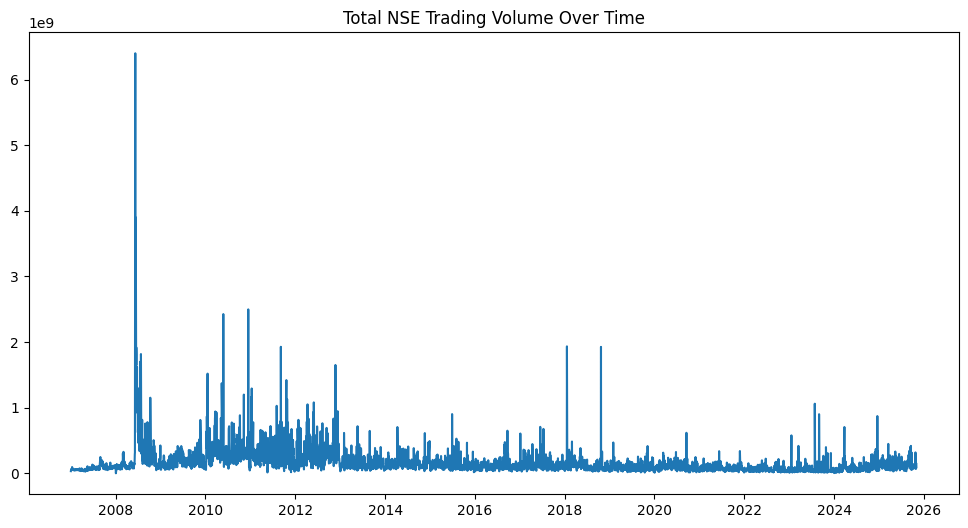

In [63]:
market_volume = cleaning_df.groupby('date_parsed')['volume'].sum()

plt.figure(figsize=(12,6))
plt.plot(market_volume)
plt.title("Total NSE Trading Volume Over Time");

<Axes: >

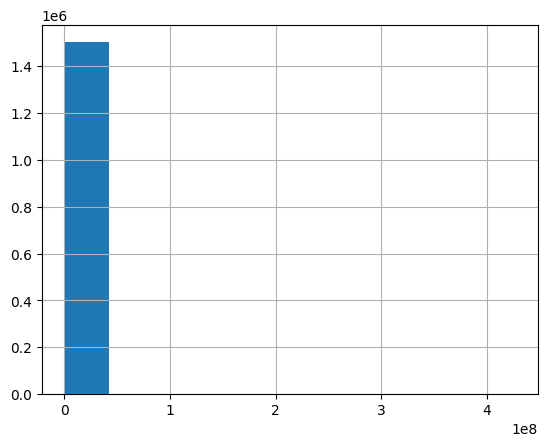

In [64]:
cleaning_df['volume'].hist(bins= 10)

#### Most traded stocks

<Axes: title={'center': 'Top 10 Most Traded Stocks'}, xlabel='code'>

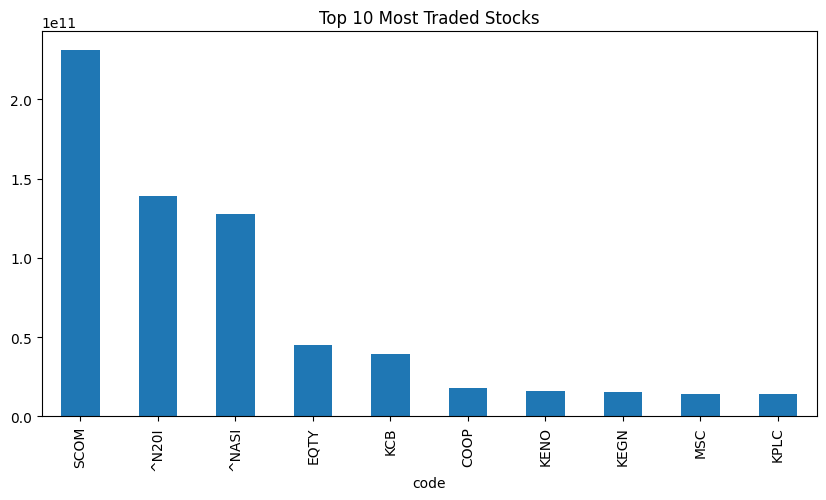

In [65]:
top_volume = cleaning_df.groupby('code')['volume'].sum().sort_values(ascending=False).head(10)

top_volume.plot(kind= 'bar', figsize= (10,5), title= 'Top 10 Most Traded Stocks')

#### Price Distribution

<Axes: >

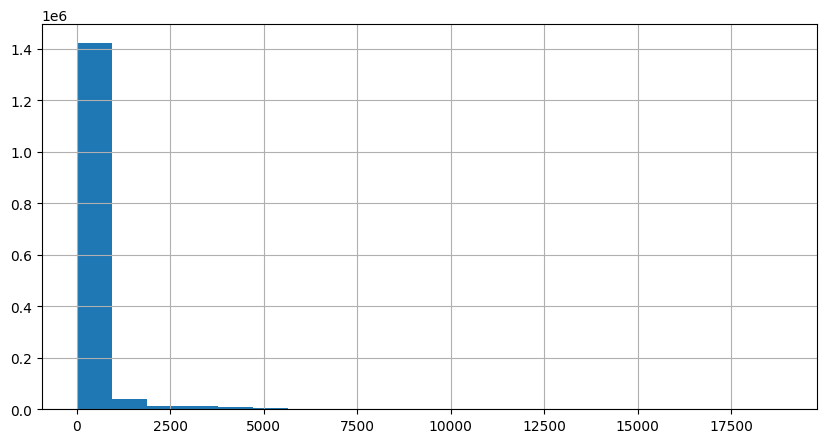

In [66]:
cleaning_df['day_price'].hist(bins= 20, figsize=(10,5))

#### Price Movement

In [67]:
cleaning_df['change'].describe()

count    1.504775e+06
mean     4.408945e-02
std      4.595204e+01
min     -1.696412e+04
25%     -1.000000e-01
50%      0.000000e+00
75%      8.000000e-02
max      1.696101e+04
Name: change, dtype: float64

<Axes: >

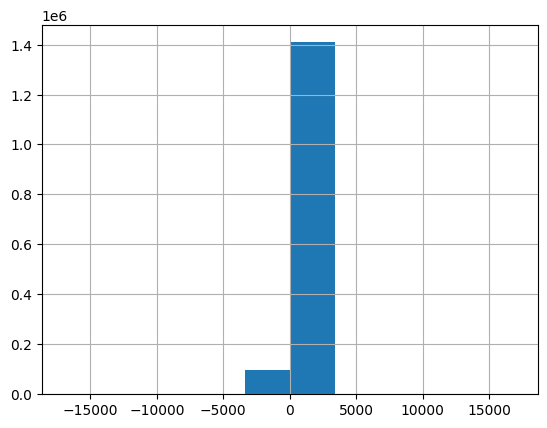

In [68]:
cleaning_df['change'].hist(bins= 10)

#### Relationship between High, Low and Price

<Axes: xlabel='day_low', ylabel='day_high'>

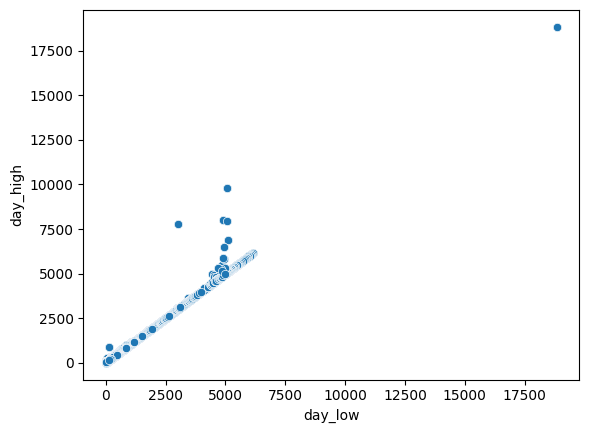

In [69]:
sns.scatterplot(data= cleaning_df, x= 'day_low', y= 'day_high')

#### Identify Most Volatile Stocks

<Axes: title={'center': 'Most Volatile Stocks'}, xlabel='code'>

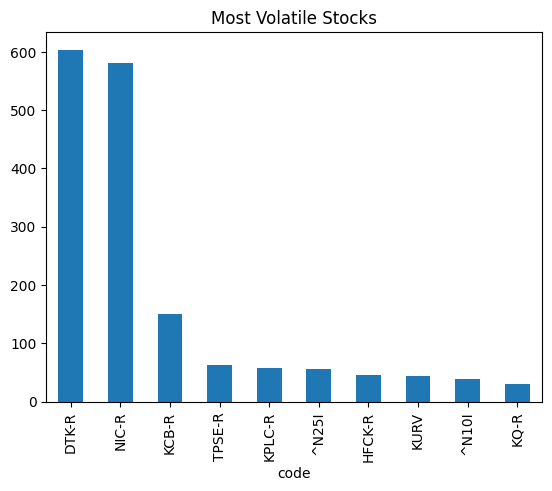

In [70]:
volatility = cleaning_df.groupby('code')['change%'].std().sort_values(ascending= False).head(10)

volatility.plot(kind= 'bar', title= 'Most Volatile Stocks')

#### 12-Month High vs Low

<Axes: xlabel='range_12m', ylabel='Count'>

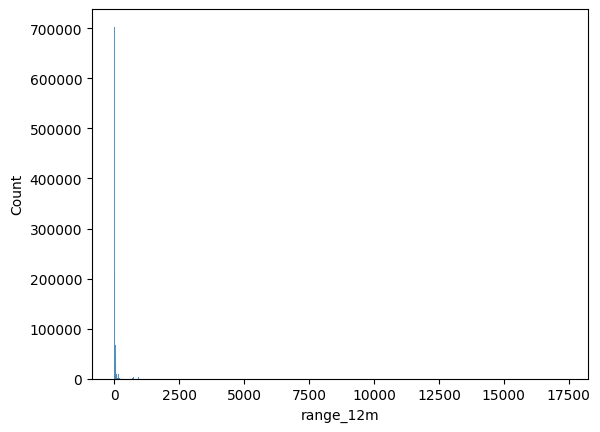

In [71]:
cleaning_df['range_12m'] = cleaning_df['12m_high'] - cleaning_df['12m_low']

sns.histplot(cleaning_df['range_12m'])

### Company Level Analysis (Safaricom PLC - SCOM)

Safaricom officially listed and commenced trading on the Nairobi Securities Exchange (NSE) on June 9, 2008, following a public offering (IPO) of 25% of its shares. The IPO, launched earlier on March 28, 2008, was a landmark, offering 10 billion shares at Kshs 5.0 each and increasing total market capitalization. 

In [72]:
safaricom = cleaning_df[cleaning_df['code'] == 'SCOM']

In [73]:
safaricom.head(15)

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_parsed,range_12m
13897,SCOM,Safaricom,3.10,6.6,5.00,5.00,5.00,29.75,-24.75,495.00,0.0,-,2008-04-23,3.50
15243,SCOM,Safaricom,3.10,6.6,6.95,8.00,7.35,5.00,2.35,31.97,416380000.0,-,2008-06-09,3.50
15285,SCOM,Safaricom,3.10,6.6,6.65,8.00,6.95,7.35,-0.40,5.76,127310000.0,-,2008-06-10,3.50
15330,SCOM,Safaricom,3.10,6.6,6.90,7.10,6.95,6.95,0.00,0.00,183490000.0,-,2008-06-11,3.50
15374,SCOM,Safaricom,3.10,6.6,7.10,7.50,7.35,6.95,0.40,5.44,131240000.0,-,2008-06-12,3.50
15419,SCOM,Safaricom,3.10,6.6,7.00,7.65,7.45,7.35,0.10,1.34,250900000.0,-,2008-06-13,3.50
15461,SCOM,Safaricom,3.10,6.6,7.50,8.15,7.90,7.45,0.45,5.70,103790000.0,-,2008-06-16,3.50
15504,SCOM,Safaricom,3.10,6.6,7.70,8.05,7.80,7.90,-0.10,1.28,121490000.0,-,2008-06-17,3.50
15547,SCOM,Safaricom,3.10,6.6,7.70,7.90,7.80,7.80,0.00,0.00,112660000.0,-,2008-06-18,3.50
15591,SCOM,Safaricom,3.10,6.6,7.80,7.90,7.85,7.80,0.05,0.64,58890000.0,-,2008-06-19,3.50


In [74]:
safaricom.tail(20)

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_parsed,range_12m
1503591,SCOM,Safaricom Plc,14.1,31.0,28.90,29.45,29.30,28.90,0.40,1.38,6186814.0,-,2025-10-01,16.9
1503665,SCOM,Safaricom Plc,14.1,31.0,28.95,29.50,29.35,29.30,0.05,0.17,7453413.0,-,2025-10-02,16.9
1503739,SCOM,Safaricom Plc,14.1,31.0,28.80,29.20,28.90,29.35,-0.45,-1.53,1436320.0,-,2025-10-03,16.9
1503813,SCOM,Safaricom Plc,14.1,31.0,28.25,29.00,28.65,28.90,-0.25,-0.87,598377.0,-,2025-10-06,16.9
1503888,SCOM,Safaricom Plc,14.1,31.0,27.45,28.90,28.20,28.65,-0.45,-1.57,5131599.0,-,2025-10-07,16.9
1503963,SCOM,Safaricom Plc,14.1,31.0,27.20,28.00,27.40,28.20,-0.80,-2.84,8525973.0,-,2025-10-08,16.9
1504038,SCOM,Safaricom Plc,14.1,31.0,26.65,27.45,27.10,27.40,-0.30,-1.09,4492292.0,-,2025-10-09,16.9
1504113,SCOM,Safaricom Plc,14.1,31.0,26.10,27.35,26.60,27.10,-0.50,-1.85,3919201.0,-,2025-10-13,16.9
1504188,SCOM,Safaricom Plc,14.1,31.0,25.80,26.50,26.00,26.60,-0.60,-2.26,2540959.0,-,2025-10-14,16.9
1504263,SCOM,Safaricom Plc,14.1,31.0,26.00,27.50,26.55,26.00,0.55,2.12,6905767.0,-,2025-10-15,16.9


In [75]:
safaricom.info()

<class 'pandas.DataFrame'>
Index: 21675 entries, 13897 to 1505013
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   code            21675 non-null  str           
 1   name            21675 non-null  str           
 2   12m_low         21675 non-null  float64       
 3   12m_high        21675 non-null  float64       
 4   day_low         21675 non-null  float64       
 5   day_high        21675 non-null  float64       
 6   day_price       21675 non-null  float64       
 7   previous        21675 non-null  float64       
 8   change          21675 non-null  float64       
 9   change%         21675 non-null  float64       
 10  volume          21675 non-null  float64       
 11  adjusted_price  21675 non-null  str           
 12  date_parsed     21675 non-null  datetime64[us]
 13  range_12m       21675 non-null  float64       
dtypes: datetime64[us](1), float64(10), str(3)
memory usage: 2.5 MB


In [76]:
safaricom.describe()

,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,date_parsed,range_12m
count,21675.000000,21675.000000,21675.000000,21675.000000,21675.000000,21675.000000,21675.000000,21675.000000,2.167500e+04,21675,21675.000000
mean,16.451396,25.344602,17.092537,17.578685,17.298627,17.299193,-0.000565,1.054268,1.066320e+07,2017-02-09 00:35:32.595155,8.893206
min,3.050000,6.500000,2.500000,2.700000,2.550000,2.550000,-24.750000,-9.860000,0.000000e+00,2008-04-23 00:00:00,3.450000
25%,3.100000,6.600000,5.600000,5.850000,5.750000,5.750000,-0.100000,0.000000,3.265800e+06,2012-10-01 00:00:00,3.500000
50%,23.500000,33.500000,16.100000,16.600000,16.350000,16.350000,0.000000,0.710000,6.838100e+06,2017-02-03 00:00:00,10.000000
75%,23.500000,33.500000,26.500000,27.200000,26.750000,26.750000,0.100000,1.520000,1.280000e+07,2021-06-16 00:00:00,10.000000
max,34.000000,45.250000,44.000000,45.250000,44.950000,44.950000,2.350000,495.000000,4.163800e+08,2025-10-31 00:00:00,19.750000
std,9.358646,12.543857,10.875260,11.131786,10.995029,10.995408,0.499825,7.658476,1.500439e+07,NaN,3.816749


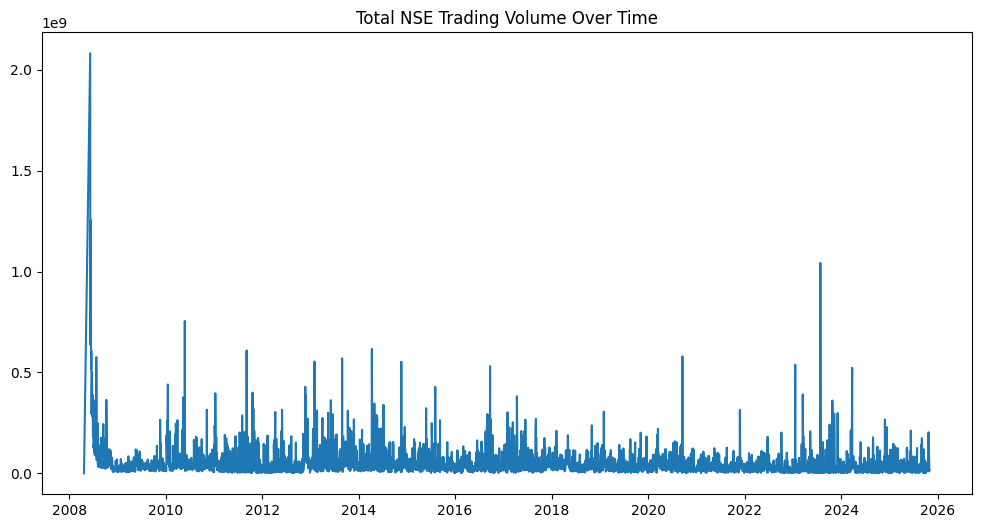

In [77]:
market_volume = safaricom.groupby('date_parsed')['volume'].sum()

plt.figure(figsize=(12,6))
plt.plot(market_volume)
plt.title("Total SAFCOM Trading Volume Over Time");

<Axes: >

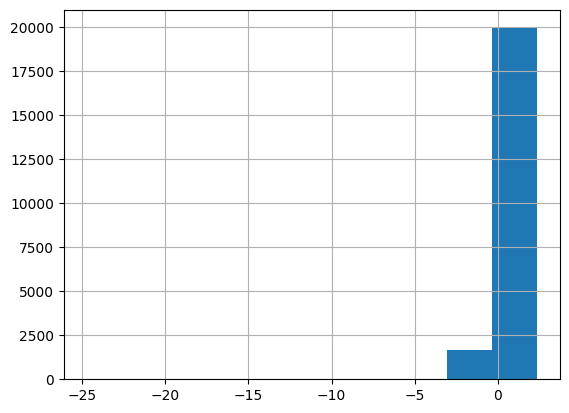

In [78]:
safaricom['change'].hist(bins= 10)

<Axes: >

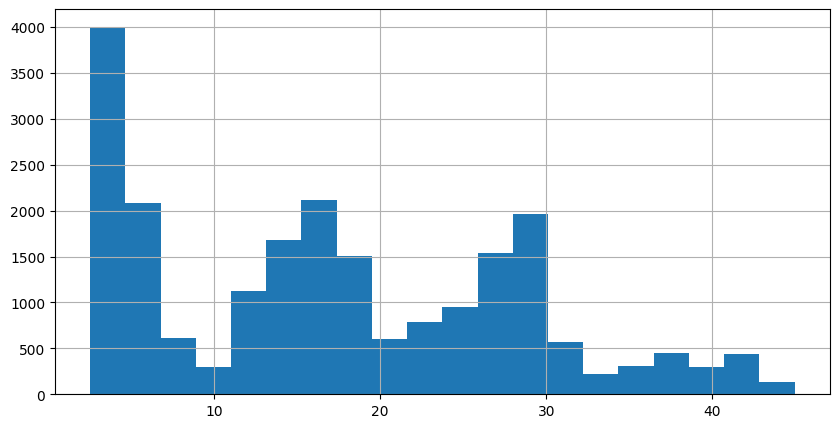

In [79]:
safaricom['day_price'].hist(bins= 20, figsize=(10,5))

<Axes: xlabel='range_12m', ylabel='Count'>

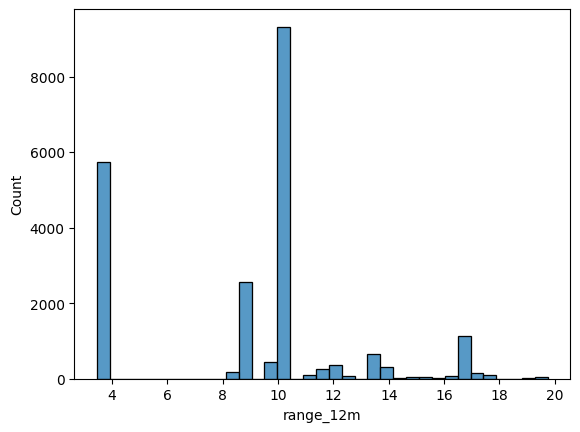

In [80]:
sns.histplot(safaricom['range_12m'])

<Axes: xlabel='day_low', ylabel='day_high'>

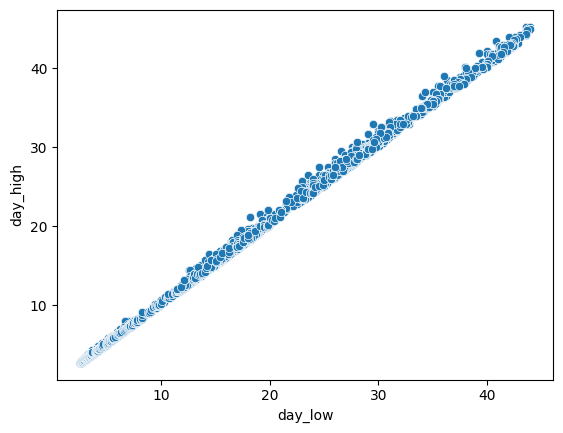

In [81]:
sns.scatterplot(data= safaricom, x= 'day_low', y= 'day_high')

<Axes: >

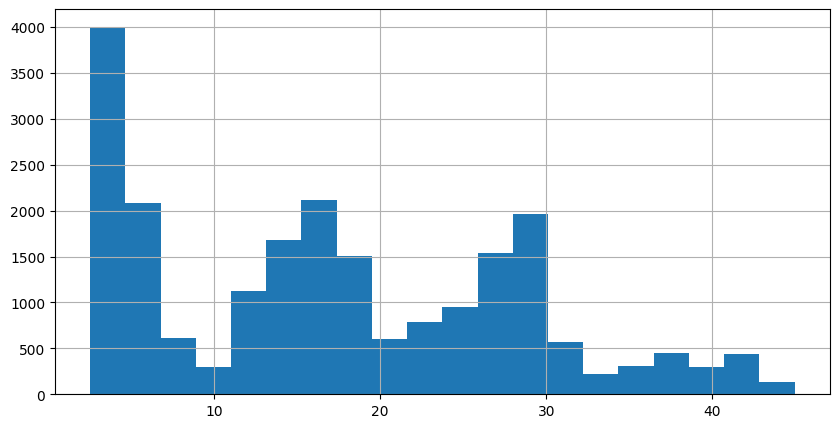

In [82]:
safaricom['day_price'].hist(bins= 20, figsize=(10,5))

<Axes: >

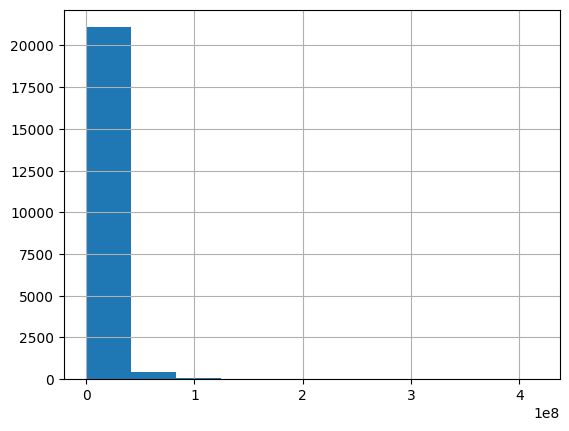

In [83]:
safaricom['volume'].hist(bins= 10)

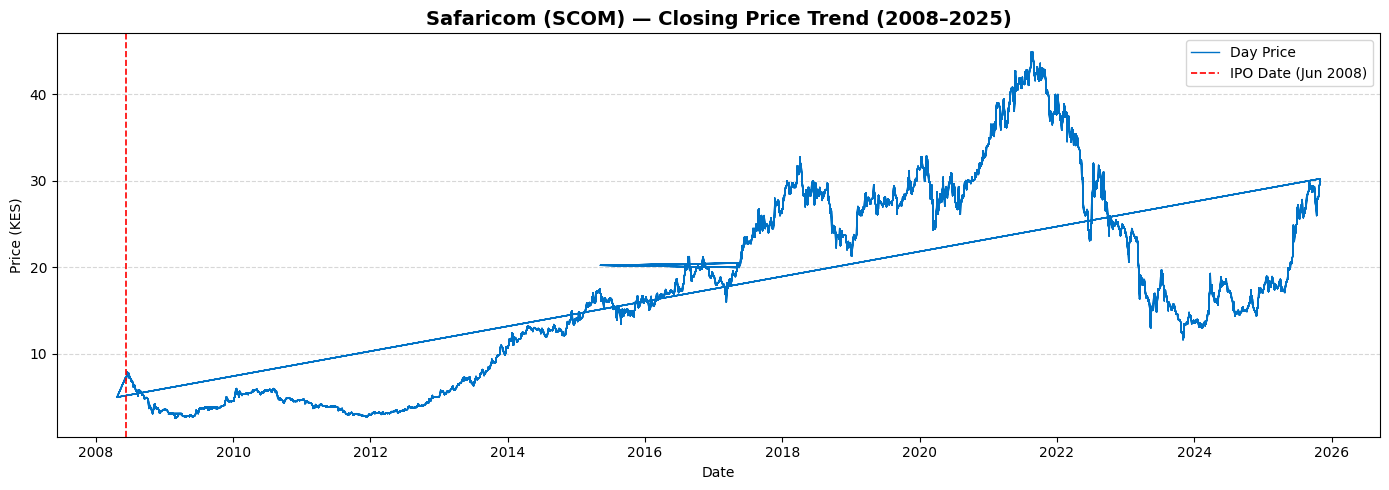

In [84]:
# ------------------------------------------------------------------
# Safaricom: Closing Price Trend Over Time
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(safaricom['date_parsed'], safaricom['day_price'], 
        color='#0072C6', linewidth=1, label='Day Price')

# Mark the IPO date as a reference point
ipo_date = pd.Timestamp('2008-06-09')
ax.axvline(x=ipo_date, color='red', linestyle='--', linewidth=1.2, label='IPO Date (Jun 2008)')

ax.set_title('Safaricom (SCOM) — Closing Price Trend (2008–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (KES)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

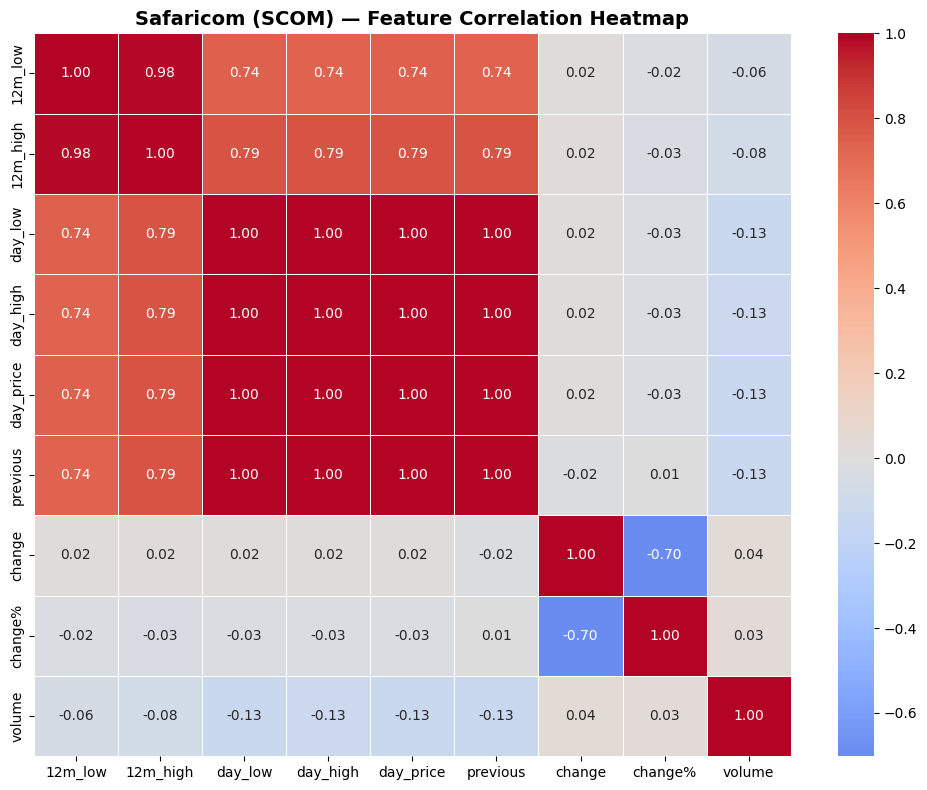

In [86]:
# ------------------------------------------------------------------
# Safaricom: Correlation Heatmap
# ------------------------------------------------------------------
# Why: The heatmap shows how strongly the numeric columns move 
# together. For modelling, we want to understand:
#   - Which features are highly correlated with day_price (target)
#   - Which features are correlated with each other (multicollinearity)
#     — important for linear models.
# ------------------------------------------------------------------

# Select only numeric columns for the heatmap
scom_numeric = safaricom[['12m_low', '12m_high', 'day_low', 'day_high', 
                           'day_price', 'previous', 'change', 'change%', 'volume']]

corr_matrix = scom_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            linewidths=0.5,
            ax=ax)

ax.set_title('Safaricom (SCOM) — Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()